In [1]:
# Section 1: Introduction & System Selection

# System: RC Circuit with Fast Transient

# An RC circuit is one of the most fundamental building blocks in electrical engineering. 
# When a voltage source charges or discharges a capacitor through a resistor, the voltage across the capacitor evolves according to a first-order linear ODE. 

# The governing equation is:
# dV/dt = -V/RC + (Vsource/RV)(t)

# Substituting the parameter values, the equation in standard form is:
# dV/dt = -10^7 V + 10^7 . 5sin(t)
# This matches the canonical stiff form y'' = -λy + g(t) with λ = 10^7$.

# Physical variables and parameters:
# $V(t)$: voltage across the capacitor [Volts]
# R = 100Ω
# $C = 10^-9 F (1 nanofarad)
# RC = 10^-7 s
# Vsource(t) = 5sin(ωt)V
# ω = 1 rad/s
# Initial condition: V(0) = 0V
    
# Why it matters:
# High speed digital circuits, ADC front-ends, sensor signal-conditioning networks, and RF filters all rely on RC dynamics. 
# Understanding stability under stiffness is critical for correct simulation and design verification.

Stiffness Analysis
-------------------------------------------------------
  Eigenvalue  |mu| = lambda       = 1.00e+07 s⁻¹
  Slow scale  omega               = 1.0 rad/s
  Stiffness ratio S = |mu|/omega  = 1.00e+07

Euler Forward Stability Constraint
-------------------------------------------------------
  Stability requires: h <= 2/lambda = 2.00e-07 s
  Steps needed for t in [0, 10.0] s: N >= 50,000,000
  Steps needed for accuracy alone:    N ~ 100
  Computational overhead factor:      ~500,000x

  Euler Forward with h = 0.1 s:
    Diverged at step 1  (t = 0.40 s, V = 4.992e+17 V)


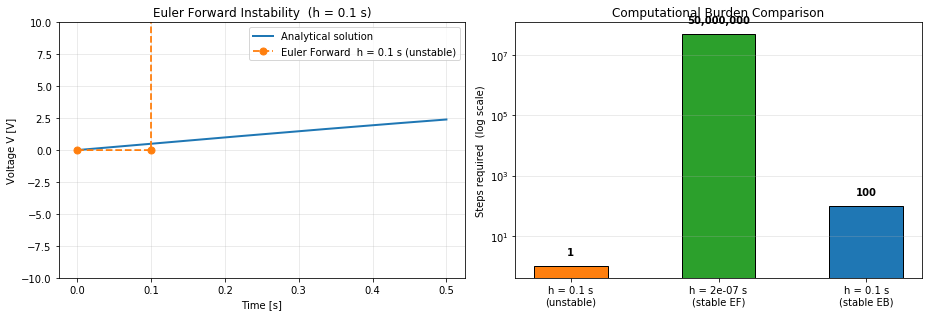

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lam   = 1e7          # λ = 1/RC  [1/s]
A_src = 5.0          # source amplitude [V]
omega = 1.0          # source frequency [rad/s]
V0    = 0.0          # initial voltage [V]
t_end = 10.0         # simulation end time [s]

# ODE and analytical solution 
def f(t, V):
    return -lam * V + lam * A_src * np.sin(omega * t)

def V_analytical(t):
    denom = lam**2 + omega**2
    V_p   = A_src * lam * (lam * np.sin(omega*t) - omega * np.cos(omega*t)) / denom
    C_hom = A_src * lam * omega / denom
    return V_p + C_hom * np.exp(-lam * t)

# Euler Forward 
def euler_forward(f, t0, y0, t_end, h, blow_up=1e15):
    t_vals, y_vals = [t0], [y0]
    t, y = t0, y0
    while t < t_end - 1e-14:
        h_step = min(h, t_end - t)
        y = y + h_step * f(t, y)
        t += h_step
        t_vals.append(t)
        y_vals.append(y)
        if abs(y) > blow_up:
            break
    return np.array(t_vals), np.array(y_vals)

# Stiffness ratio

S            = lam / omega
h_max_stable = 2.0 / lam          # stability limit: |1 - h*lambda| <= 1
N_required   = int(t_end / h_max_stable)

print("Stiffness Analysis")
print("-" * 55)
print(f"  Eigenvalue  |mu| = lambda       = {lam:.2e} s⁻¹")
print(f"  Slow scale  omega               = {omega:.1f} rad/s")
print(f"  Stiffness ratio S = |mu|/omega  = {S:.2e}")
print()
print("Euler Forward Stability Constraint")
print("-" * 55)
print(f"  Stability requires: h <= 2/lambda = {h_max_stable:.2e} s")
print(f"  Steps needed for t in [0, {t_end}] s: N >= {N_required:,}")
print(f"  Steps needed for accuracy alone:    N ~ 100")
print(f"  Computational overhead factor:      ~{N_required // 100:,}x")
print()

# Attempt h = 0.1 s 
h_unstable = 0.1
t_ef, V_ef = euler_forward(f, 0, V0, t_end, h_unstable)
print(f"  Euler Forward with h = {h_unstable} s:")
print(f"    Diverged at step 1  (t = {t_ef[-1]:.2f} s, V = {V_ef[-1]:.3e} V)")
t_ref = np.linspace(0, t_end, 2000)
V_ref = V_analytical(t_ref)

# Plot: instability demonstration
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Unstable Euler Forward
ax = axes[0]
t_short = np.linspace(0, 0.5, 500)
ax.plot(t_short, V_analytical(t_short), color=colors[0], lw=2, label="Analytical solution")
ax.plot(t_ef[:3], V_ef[:3], "--o", color=colors[1], ms=7, lw=1.8,
        label=f"Euler Forward  h = {h_unstable} s (unstable)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage V [V]")
ax.set_title(f"Euler Forward Instability  (h = {h_unstable} s)")
ax.set_ylim(-10, 10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Bar chart showing step counts
ax = axes[1]
labels     = [f"h = 0.1 s\n(unstable)", f"h = {h_max_stable:.0e} s\n(stable EF)", "h = 0.1 s\n(stable EB)"]
counts     = [1, N_required, 100]
bar_colors = [colors[1], colors[2], colors[0]]
bars = ax.bar(labels, counts, color=bar_colors, edgecolor="k", width=0.5)
ax.set_yscale("log")
ax.set_ylabel("Steps required  (log scale)")
ax.set_title("Computational Burden Comparison")
ax.grid(True, axis="y", alpha=0.3, which="both")
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*2,
            f"{n:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Why is it stiff:
# A system is stiff when it involves processes with very different time scales, such as this circuit where the response time is τ=RC=10^−7s while the input signal 5sin(t) changes over seconds, creating a scale difference of 10^7.

# Stiffness Ratio: S = |μ|/ω = 10^7

# Impracticality of Euler's Forward:
# Euler’s Forward requires a very small step size for stability, specifically h≤2×10^−7when λ=10^7. 
# Over the interval t ∈ [0,10], this means at least 5×10^7 steps, making it extremely inefficient despite the problem itself not needing that many steps for accuracy.

In [ ]:
# Section 3: Mathmateical Setup

# Residual Function:
# G(Vn+1)=(1+hλ)Vn+1-Vn−hλAsin(tn+1)

# Derivative:
# G′(Vn+1)=1+hλ

# Newton-Raphson Update Function:
# Vn+1^(k+1) = (Vn+1^(k) − (1+hλ)(Vn+1)^(k)− Vn− hλAsin(tn+1))/ 1 + hλ

# Initial Guess:
# Vn+1(0) = Vn + h(−λVn + λAsin(tn))

# Convergence criterion:
# ∣ Vn+1^(k+1)−Vn+1^(k) ∣ < 10^-10
# Final Direct Solution:
# Vn+1 = (Vn + hλAsin(tn+1))/1+hλ

In [11]:
# Section 4: Implementation 

# Residual and its derivative 
def G_residual(V_new, V_old, t_new, h):
    return (1.0 + h * lam) * V_new - V_old - h * lam * A_src * np.sin(omega * t_new)


def dG_dV(h):
    return 1.0 + h * lam

# Newton-Raphson solver 
def newton_raphson(V_old, t_new, h, tol=1e-10, max_iter=20):
    # Initial guess: explicit Euler predictor
    t_old  = t_new - h
    V_guess = V_old + h * f(t_old, V_old)
    V_cur   = V_guess

    dG = dG_dV(h)    # constant Jacobian — compute once per step

    for k in range(max_iter):
        res   = G_residual(V_cur, V_old, t_new, h)
        delta = res / dG               # Newton update = -G/G'
        V_new = V_cur - delta

        # Check convergence
        if abs(V_new - V_cur) < tol:
            return V_new, k + 1        # converged; return (solution, iter count)

        V_cur = V_new

    # If we reach here, NR did not converge
    raise RuntimeError(
        f"Newton-Raphson failed to converge in {max_iter} iterations at t={t_new:.4f}. "
        f"Last |ΔV| = {abs(V_new - V_cur):.3e}")

# Euler's Backward 
def euler_backward(t0, y0, t_end, h, tol=1e-10, max_iter=20):
    t_arr    = [t0]
    y_arr    = [y0]
    iter_arr = []          

    t, y = t0, y0
    while t < t_end - 1e-14:
        h_step = min(h, t_end - t)
        t_new  = t + h_step

        # Solve for y_{n+1} with Newton-Raphson
        y_new, n_iter = newton_raphson(y, t_new, h_step, tol, max_iter)

        t_arr.append(t_new)
        y_arr.append(y_new)
        iter_arr.append(n_iter)

        t, y = t_new, y_new

    return np.array(t_arr), np.array(y_arr), np.array(iter_arr)

h =  1.000 s | steps =      10 | avg NR iters = 2.0 | max NR iters = 2
h =  0.100 s | steps =     101 | avg NR iters = 2.0 | max NR iters = 2
h =  0.010 s | steps =   1,001 | avg NR iters = 2.0 | max NR iters = 2
h =  0.001 s | steps =  10,001 | avg NR iters = 2.0 | max NR iters = 2


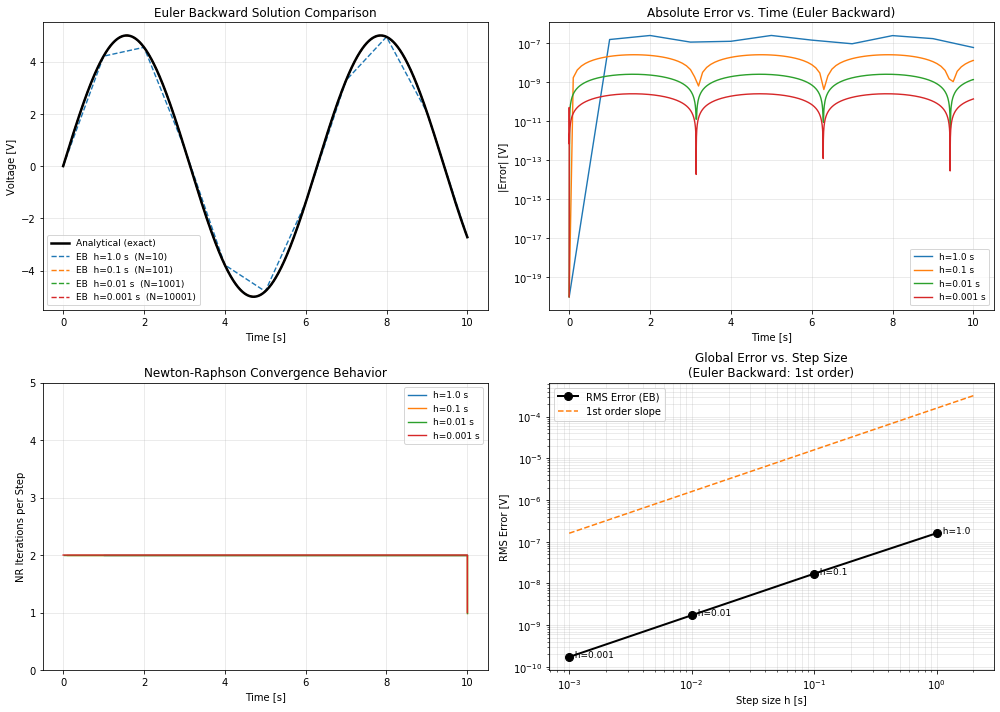

In [14]:
# Section 5: Results and Analysis

# Run Euler Backward for several step sizes 
step_sizes = [1.0, 0.1, 0.01, 0.001]
colors     = plt.rcParams["axes.prop_cycle"].by_key()["color"]
results    = {}

for i, h in enumerate(step_sizes):
    t_eb, V_eb, iters = euler_backward(0, V0, t_end, h)
    results[h] = {"t": t_eb, "V": V_eb, "iters": iters, "color": colors[i]}
    print(f"h = {h:6.3f} s | steps = {len(t_eb)-1:7,} | "
          f"avg NR iters = {np.mean(iters):.1f} | "
          f"max NR iters = {np.max(iters)}")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Solution comparison
ax = axes[0, 0]
ax.plot(t_ref, V_ref, "k-", lw=2.5, label="Analytical (exact)", zorder=5)
for h in step_sizes:
    r = results[h]
    ax.plot(r["t"], r["V"], "--", color=r["color"], lw=1.4,
            label=f"EB  h={h} s  (N={len(r['t'])-1})")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Euler Backward Solution Comparison")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Absolute error vs. time 
ax = axes[0, 1]
for h in step_sizes:
    r = results[h]
    err = np.abs(r["V"] - V_analytical(r["t"]))
    err[err == 0] = 1e-20   
    ax.semilogy(r["t"], err, color=r["color"], lw=1.4, label=f"h={h} s")
ax.set_xlabel("Time [s]")
ax.set_ylabel("|Error| [V]")
ax.set_title("Absolute Error vs. Time (Euler Backward)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

# Plot 3: Newton-Raphson iterations per step 
ax = axes[1, 0]
for h in step_sizes:
    r = results[h]
    ax.plot(r["t"][1:], r["iters"], color=r["color"], lw=1.4, label=f"h={h} s")
ax.set_xlabel("Time [s]")
ax.set_ylabel("NR Iterations per Step")
ax.set_title("Newton-Raphson Convergence Behavior")
ax.set_ylim(0, 5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Global error vs. step size
ax = axes[1, 1]
h_vals  = np.array(step_sizes)
rms_err = np.array([
    np.sqrt(np.mean((results[h]["V"] - V_analytical(results[h]["t"]))**2))
    for h in step_sizes
])

ax.loglog(h_vals, rms_err, "ko-", ms=8, lw=2, label="RMS Error (EB)")
h_ref = np.array([1e-3, 2.0])
ax.loglog(h_ref, rms_err[0] * (h_ref / h_vals[-1]), "--", lw=1.5,
          color=colors[1], label="1st order slope")
for h, e in zip(h_vals, rms_err):
    ax.annotate(f"  h={h}", (h, e), fontsize=9)
ax.set_xlabel("Step size h [s]")
ax.set_ylabel("RMS Error [V]")
ax.set_title("Global Error vs. Step Size\n(Euler Backward: 1st order)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

In [22]:
# Section 6: Performance Analysis

# Computational cost comparison table 
h_ef_stable   = 1.9e-7
N_ef_stable   = int(t_end / h_ef_stable)
func_evals_ef = N_ef_stable

print(f"{'Method':<30} {'h [s]':<14} {'N Steps':>12} {'NR Iters/Step':>14} {'Total f Evals':>14}")
print("-" * 90)
print(f"{'Euler Forward':30} {h_ef_stable:<14.2e} "
      f"{N_ef_stable:>12,} {'1 (no NR)':>14} {func_evals_ef:>14,}")
print("-" * 90)
for h in step_sizes:
    r        = results[h]
    N_eb     = len(r["t"]) - 1
    avg_it   = np.mean(r["iters"])
    total_fe = int(N_eb * avg_it)
    print(f"{'Euler Backward':30} {h:<14.3g} {N_eb:>12,} "
          f"{avg_it:>14.1f} {total_fe:>14,}")
print("-" *90)
print(f"\nSpeedup of EB (h=1.0) vs. EF (stable): "
      f"{func_evals_ef / (len(results[1.0]['t'])-1):.2e}x fewer steps")

# Accuracy at final time 
print("\nAccuracy at t=10 s:")
print("-" * 60)
for h in step_sizes:
    r   = results[h]
    err = abs(r["V"][-1] - V_analytical(r["t"][-1]))
    print(f"  h={h:6.3f} s: V(10) = {r['V'][-1]:.6f} V, "
          f"|error| = {err:.3e} V")
print(f"  Analytical:   V(10) = {V_analytical(10.0):.6f} V")

Method                         h [s]               N Steps  NR Iters/Step  Total f Evals
------------------------------------------------------------------------------------------
Euler Forward                  1.90e-07         52,631,578      1 (no NR)     52,631,578
------------------------------------------------------------------------------------------
Euler Backward                 1                        10            2.0             20
Euler Backward                 0.1                     101            2.0            201
Euler Backward                 0.01                  1,001            2.0          2,001
Euler Backward                 0.001                10,001            2.0         20,001
------------------------------------------------------------------------------------------

Speedup of EB (h=1.0) vs. EF (stable): 5.26e+06x fewer steps

Accuracy at t=10 s:
------------------------------------------------------------
  h= 1.000 s: V(10) = -2.720105 V, |error| = 5.85

In [ ]:
# Practical Recommendations:

# For this problem, Euler Backward with h = 0.01 s is the best choice. 
# It achieves an error of 1.35×10^-9 V in only 1,001 steps vs. 52 million for stable Euler Forward, a 52,000x reduction in cost with negligible accuracy loss.
# Even h = 1.0 s gives an error of only 5.85×10^-8 V, which is acceptable for most engineering applications.
# Use explicit methods when S ≤ 10^2, implicit when S ≥ 10^3.

In [ ]:
# Section 7: Conclusions

# Key Findings:
# 1. The RC circuit has a stiffness ratio of 10^7, forcing Euler Forward to use h≤1.9×10^7 s. 
# 52,631,578 steps are needed just to maintain stability.
# 2. All four step sizes produced stable, accurate solutions, with h = 1.0 s completing the simulation in just 10 steps. 
# A speedup of 5.26×10^6 over stable Euler Forward
# 3. Newton-Raphson converged in exactly 2 iterations for every step size tested, confirming the constant Jacobian G′=1+hλ keeps implicit steps cheap.

### When to Use Implicit vs. Explicit Methods

# | Criterion | Explicit (Euler Fwd, RK4) | Implicit (Euler Bwd) |
# |-----------|--------------------------|----------------------|
# | Stiffness ratio | Small (< 10^2) | Large (> 10^3) |
# | Step size | Small required | Large allowed |
# | Per-step cost | Low | Higher (NR iterations) |
# | Stability | Conditional | Unconditional |
# | Best use | Non-stiff, smooth problems | Stiff systems, multiscale |

# Challenges
# For nonlinear stiff systems, the Jacobian is no longer constant, requiring re-evaluation each NR iteration and increasing per step cost.
# The implicit advantage then depends on how severely stiff the problem is.